# Handdling Mix Variables

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("titanic.csv")

In [4]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [5]:
df['number'].unique()

<StringArray>
['5', '3', '6', 'A', '2', '1', '4']
Length: 7, dtype: str

<Axes: xlabel='number', ylabel='count'>

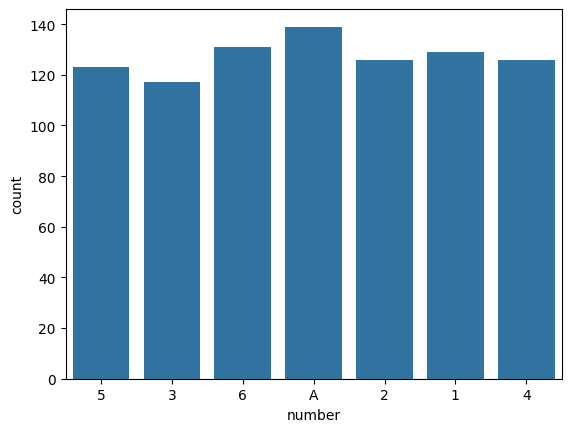

In [30]:
sns.countplot(x = df['number'])

In [31]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [95]:
df['number_numerical'] = pd.to_numeric(df['number'], errors = 'coerce', downcast = 'integer')
df['number_cat'] = np.where(df['number_numerical'].isnull(), df['number'], np.nan)

In [96]:
df.head()

,Cabin,Ticket,number,Survived,numerical,number_numerical,number_cat,Cabin_Num,Cabin_Cat,Ticket_Num,Ticket_Cat,ticket_num
0,NaN,A/5 21171,5,0,5.0,5.0,NaN,NaN,NaN,21171.0,A/5,21171.0
1,C85,PC 17599,3,1,3.0,3.0,NaN,85,C,17599.0,PC,17599.0
2,NaN,STON/O2. 3101282,6,1,6.0,6.0,NaN,NaN,NaN,3101282.0,STON/O2.,3101282.0
3,C123,113803,3,1,3.0,3.0,NaN,123,C,113803.0,NaN,113803.0
4,NaN,373450,A,0,NaN,NaN,A,NaN,NaN,373450.0,NaN,373450.0


In [46]:
df['Cabin_Num'] = df['Cabin'].str.extract('(\d+)')  # Extract Numerical Part
df['Cabin_Cat'] = df['Cabin'].str[0]   # Extract Categorical Part 

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\admin\AppData\Local\Temp\ipykernel_19896\3211449355.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Cabin_Num'] = df['Cabin'].str.extract('(\d+)')  # Extract Numerical Part


In [47]:
df.head()

,Cabin,Ticket,number,Survived,numerical,number_numerical,number_cat,Cabin_Num,Cabin_Cat
0,NaN,A/5 21171,5,0,5.0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,NaN,A,NaN,NaN


In [91]:
# Extract NUmerical part of Ticket
df['Ticket_Num'] = df['Ticket'].apply(lambda s : s.split()[-1])
df['Ticket_Num'] = pd.to_numeric(df['Ticket_Num'], errors = 'coerce', downcast = 'integer')

# Extratc categorical part of ticket 
df['Ticket_Cat'] = df['Ticket'].apply(lambda s: s.split()[0])
df['Ticket_Cat'] = np.where(df['Ticket_Cat'].str.isdigit(), np.nan, df['Ticket_Cat'])

In [92]:
df.head()

,Cabin,Ticket,number,Survived,numerical,number_numerical,number_cat,Cabin_Num,Cabin_Cat,Ticket_Num,Ticket_Cat,ticket_num
0,NaN,A/5 21171,5,0,5.0,5.0,NaN,NaN,NaN,21171.0,A/5,21171.0
1,C85,PC 17599,3,1,3.0,3.0,NaN,85,C,17599.0,PC,17599.0
2,NaN,STON/O2. 3101282,6,1,6.0,6.0,NaN,NaN,NaN,3101282.0,STON/O2.,3101282.0
3,C123,113803,3,1,3.0,3.0,NaN,123,C,113803.0,NaN,113803.0
4,NaN,373450,A,0,NaN,NaN,A,NaN,NaN,373450.0,NaN,373450.0


<Axes: xlabel='Cabin_Cat', ylabel='count'>

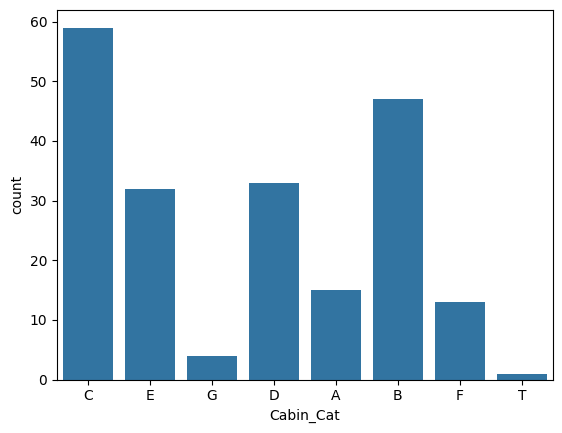

In [93]:
sns.countplot(x = df['Cabin_Cat'])

<Axes: xlabel='Cabin_Cat'>

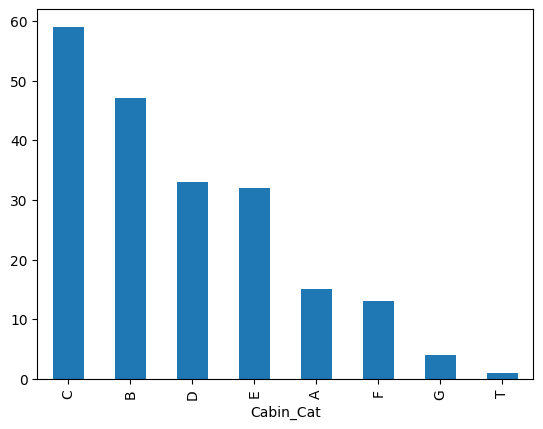

In [94]:
df['Cabin_Cat'].value_counts().plot(kind = 'bar')